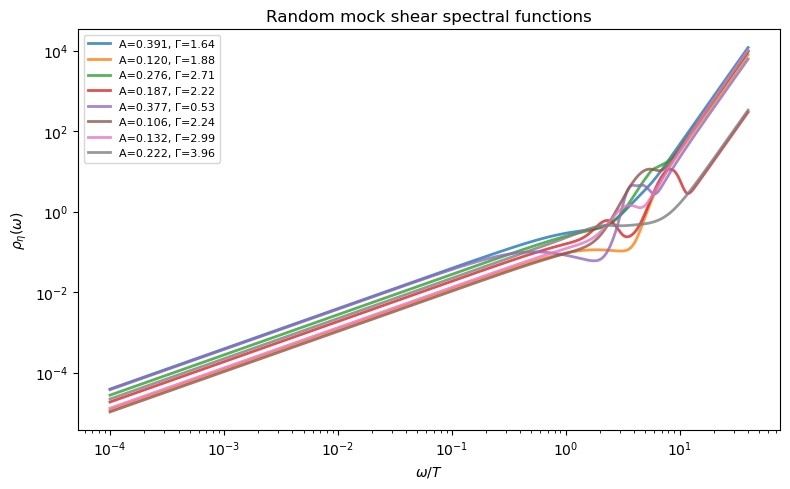

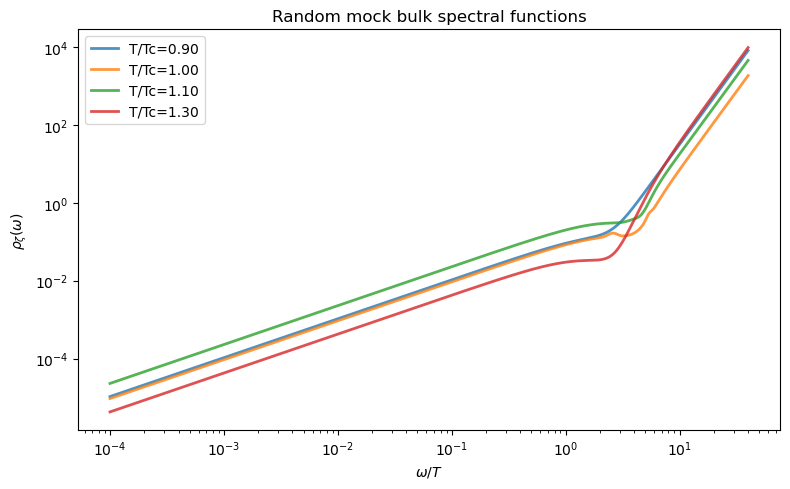

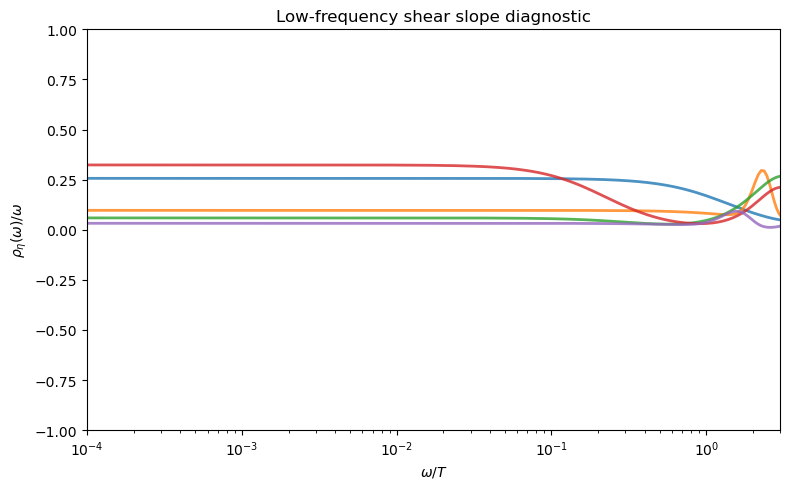

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict
from typing import Optional, Dict, Tuple


# ============================================================
# 1. Utilities
# ============================================================

def make_frequency_grid(
    wmin=1e-4,
    wsplit=1.0,
    wmax=40.0,
    nlog=200,
    nlin=400
):
    """
    Build a mixed log-linear frequency grid in units of T:
        x = omega / T

    Returns
    -------
    w : np.ndarray
        Frequency grid
    """
    w_log = np.logspace(np.log10(wmin), np.log10(wsplit), nlog, endpoint=False)
    w_lin = np.linspace(wsplit, wmax, nlin)
    w = np.unique(np.concatenate([w_log, w_lin]))
    return w


def smooth_switch(w, Lambda=3.0, sharpness=4.0):
    """
    Smoothly turn on the UV contribution around Lambda.

    f(w) ~ 0 for w << Lambda
    f(w) ~ 1 for w >> Lambda
    """
    x = (w / Lambda) ** sharpness
    return x / (1.0 + x)


def gaussian_bump(w, amp, mu, sigma, power=1):
    """
    A flexible bump term:
        amp * w^power * exp(-(w-mu)^2 / (2 sigma^2))
    """
    return amp * (w ** power) * np.exp(-0.5 * ((w - mu) / sigma) ** 2)


def lorentzian_transport_peak(w, A, Gamma):
    """
    IR transport peak:
        rho_IR(w) = A * w / (1 + (w/Gamma)^2)

    Low-frequency slope:
        rho(w)/w -> A as w -> 0
    So viscosity is proportional to A.
    """
    return A * w / (1.0 + (w / Gamma) ** 2)


# ============================================================
# 2. Parameter containers
# ============================================================

@dataclass
class ShearParams:
    A: float               # IR slope coefficient
    Gamma: float           # transport width
    B: float               # UV amplitude
    Lambda_uv: float       # UV onset scale
    sharpness_uv: float    # UV switch sharpness
    n_bumps: int = 0       # number of mid-frequency bumps
    bump_amps: Optional[np.ndarray] = None
    bump_mus: Optional[np.ndarray] = None
    bump_sigmas: Optional[np.ndarray] = None


@dataclass
class BulkParams:
    A: float
    Gamma: float
    D: float
    Lambda_uv: float
    sharpness_uv: float
    n_bumps: int = 0
    bump_amps: Optional[np.ndarray] = None
    bump_mus: Optional[np.ndarray] = None
    bump_sigmas: Optional[np.ndarray] = None
    Tc: float = 1.0
    T: float = 1.0


# ============================================================
# 3. Spectral function models
# ============================================================

def rho_shear(w, params: ShearParams):
    """
    Mock shear spectral function in dimensionless units x = omega/T.

    Structure:
        rho = IR transport + UV tail + optional mid-frequency bumps

    Here we use a simple UV tail ~ w^4 * switch(w).
    """
    # IR transport
    rho_ir = lorentzian_transport_peak(w, params.A, params.Gamma)

    # UV tail
    uv_switch = smooth_switch(w, Lambda=params.Lambda_uv, sharpness=params.sharpness_uv)
    rho_uv = params.B * (w ** 4) * uv_switch

    # Mid-frequency structure
    rho_mid = np.zeros_like(w)
    if params.n_bumps > 0:
        for amp, mu, sigma in zip(params.bump_amps, params.bump_mus, params.bump_sigmas):
            rho_mid += gaussian_bump(w, amp=amp, mu=mu, sigma=sigma, power=3)

    rho = rho_ir + rho_mid + rho_uv

    # Safety
    rho = np.maximum(rho, 0.0)
    return rho


def bulk_peak_enhancement(T, Tc=1.0, height=1.0, width=0.12):
    """
    Temperature-dependent enhancement factor for bulk near Tc.
    """
    return 1.0 + height * np.exp(-0.5 * ((T - Tc) / width) ** 2)


def rho_bulk(w, params: BulkParams, peak_height=2.0, peak_width=0.12):
    """
    Mock bulk spectral function.

    Similar to shear, but the IR coefficient A is enhanced near T ~ Tc.
    """
    enh = bulk_peak_enhancement(
        T=params.T, Tc=params.Tc, height=peak_height, width=peak_width
    )

    A_eff = params.A * enh

    rho_ir = lorentzian_transport_peak(w, A_eff, params.Gamma)

    uv_switch = smooth_switch(w, Lambda=params.Lambda_uv, sharpness=params.sharpness_uv)
    rho_uv = params.D * (w ** 4) * uv_switch

    rho_mid = np.zeros_like(w)
    if params.n_bumps > 0:
        for amp, mu, sigma in zip(params.bump_amps, params.bump_mus, params.bump_sigmas):
            # bulk bumps can be softer than shear
            rho_mid += gaussian_bump(w, amp=amp, mu=mu, sigma=sigma, power=1)

    rho = rho_ir + rho_mid + rho_uv
    rho = np.maximum(rho, 0.0)
    return rho


# ============================================================
# 4. Random parameter generators
# ============================================================

def sample_shear_params(rng=np.random.default_rng()) -> ShearParams:
    """
    Randomly sample physically plausible mock shear spectral parameters.
    All frequencies are in units of T.
    """
    A = rng.uniform(0.02, 0.4)          # controls viscosity
    Gamma = rng.uniform(0.2, 4.0)       # transport width
    B = rng.uniform(1e-4, 5e-3)         # UV amplitude
    Lambda_uv = rng.uniform(2.0, 6.0)
    sharpness_uv = rng.uniform(2.0, 8.0)

    n_bumps = rng.integers(0, 3)        # 0, 1, or 2 bumps

    if n_bumps > 0:
        bump_amps = rng.uniform(1e-3, 5e-2, size=n_bumps)
        bump_mus = rng.uniform(1.0, 8.0, size=n_bumps)
        bump_sigmas = rng.uniform(0.2, 1.5, size=n_bumps)
    else:
        bump_amps = np.array([])
        bump_mus = np.array([])
        bump_sigmas = np.array([])

    return ShearParams(
        A=A,
        Gamma=Gamma,
        B=B,
        Lambda_uv=Lambda_uv,
        sharpness_uv=sharpness_uv,
        n_bumps=n_bumps,
        bump_amps=bump_amps,
        bump_mus=bump_mus,
        bump_sigmas=bump_sigmas
    )


def sample_bulk_params(T=1.0, Tc=1.0, rng=np.random.default_rng()) -> BulkParams:
    """
    Randomly sample mock bulk spectral parameters.
    Bulk is usually harder and can vary more strongly near Tc.
    """
    A = rng.uniform(0.005, 0.2)
    Gamma = rng.uniform(0.1, 3.0)
    D = rng.uniform(5e-5, 5e-3)
    Lambda_uv = rng.uniform(2.0, 6.0)
    sharpness_uv = rng.uniform(2.0, 8.0)

    n_bumps = rng.integers(0, 3)

    if n_bumps > 0:
        bump_amps = rng.uniform(1e-3, 5e-2, size=n_bumps)
        bump_mus = rng.uniform(0.5, 6.0, size=n_bumps)
        bump_sigmas = rng.uniform(0.2, 1.2, size=n_bumps)
    else:
        bump_amps = np.array([])
        bump_mus = np.array([])
        bump_sigmas = np.array([])

    return BulkParams(
        A=A,
        Gamma=Gamma,
        D=D,
        Lambda_uv=Lambda_uv,
        sharpness_uv=sharpness_uv,
        n_bumps=n_bumps,
        bump_amps=bump_amps,
        bump_mus=bump_mus,
        bump_sigmas=bump_sigmas,
        Tc=Tc,
        T=T
    )


# ============================================================
# 5. Convenience wrappers
# ============================================================

def generate_random_shear_spectrum(w, rng=np.random.default_rng()):
    params = sample_shear_params(rng)
    rho = rho_shear(w, params)
    return rho, params


def generate_random_bulk_spectrum(w, T=1.0, Tc=1.0, rng=np.random.default_rng()):
    params = sample_bulk_params(T=T, Tc=Tc, rng=rng)
    rho = rho_bulk(w, params)
    return rho, params


# ============================================================
# 6. Example usage / plotting
# ============================================================

if __name__ == "__main__":
    rng = np.random.default_rng(1234)

    # Frequency grid x = omega/T
    w = make_frequency_grid()

    # ----- Shear examples -----
    plt.figure(figsize=(8, 5))
    for _ in range(8):
        rho, params = generate_random_shear_spectrum(w, rng=rng)
        plt.loglog(w, rho, lw=2, alpha=0.8, label=f"A={params.A:.3f}, Γ={params.Gamma:.2f}")

    plt.xlabel(r"$\omega/T$")
    plt.ylabel(r"$\rho_\eta(\omega)$")
    plt.title("Random mock shear spectral functions")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # ----- Bulk examples at different temperatures -----
    plt.figure(figsize=(8, 5))
    for T in [0.9, 1.0, 1.1, 1.3]:
        rho, params = generate_random_bulk_spectrum(w, T=T, Tc=1.0, rng=rng)
        plt.loglog(w, rho, lw=2, alpha=0.8, label=f"T/Tc={T:.2f}")

    plt.xlabel(r"$\omega/T$")
    plt.ylabel(r"$\rho_\zeta(\omega)$")
    plt.title("Random mock bulk spectral functions")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ----- Plot rho(omega)/omega near small omega -----
    plt.figure(figsize=(8, 5))
    for _ in range(5):
        rho, params = generate_random_shear_spectrum(w, rng=rng)
        plt.semilogx(w, rho / np.maximum(w, 1e-12), lw=2, alpha=0.8)

    plt.xlim(1e-4, 3)
    plt.ylim(-1, 1)
    plt.xlabel(r"$\omega/T$")
    plt.ylabel(r"$\rho_\eta(\omega)/\omega$")
    plt.title("Low-frequency shear slope diagnostic")
    plt.tight_layout()
    plt.show()
